<style>
.shaded-cell {
    background-color: #f0f4f8 !important;
    padding: 15px !important;
    border-radius: 8px !important;
     border-left: 5px solid #3498db
}
</style>

<h1>🚢 Titanic Survival Prediction Analysis </h1>
<h4 style="color:#555; margin-top:-8px;">
Systematic Feature Engineering and Model Optimization for Titanic Survival Prediction</h4>

<hr style="border:1px solid #ddd;">


<div style="background-color:#fff9c4; padding:16px; border-radius:8px; border-left:5px solid #fbc02d;">

<h3>📘Executive Summary</h3>

This project builds an interpretable machine-learning pipeline to predict passenger survival on the Titanic dataset. The work focuses on systematic feature engineering, careful feature selection, and tree-based model optimization to improve predictive performance while maintaining interpretability. Starting from raw passenger records, the project engineers meaningful socio-demographic and structural features (e.g., passenger title, family structure, cabin deck) and evaluates their impact on classification accuracy. The final model achieves ~85% accuracy using Decision Tree models while avoiding data leakage.
</div>


<div style="background-color:pink; padding:16px; border-radius:8px; border-left:5px solid red;">

<h3>🎯 Problem Statement</h3>
The Titanic dataset is a classic binary classification problem where the objective is to predict whether a passenger survived based on demographic, socioeconomic, and travel information. While the dataset is small, it presents real-world challenges:

<ul><li>Missing values (Age, Cabin, Embarked)</li>
    <li>High-cardinality categorical variables (Name, Ticket)</li>
</ul></div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>  📂
    Dataset Overview </h3>
</div>

**Competition:** Titanic: Machine Learning from Disaster  
**File Used:** `train.csv`  
**Dataset Source:** Kaggle  
https://www.kaggle.com/competitions/titanic/data


**Data Source**
* Titanic passenger dataset (Kaggle)

**Raw Features** 
| Feature    | Description                          |
| ---------- | ------------------------------------ |
| `Survived` | Survival indicator (0 = No, 1 = Yes) |
| `Pclass`   | Passenger class (1st, 2nd, 3rd)      |
| `Sex`      | Passenger gender                     |
| `Age`      | Passenger age                        |
| `Fare`     | Ticket fare                          |
| `SibSp`    | Number of siblings/spouses aboard    |
| `Parch`    | Number of parents/children aboard    |
| `Embarked`    | Embarkation Port   |
| `Name`    | Name of the Passenger  |


**Importing the Required Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("train.csv") 
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
df.head(3) 
df.tail(3)
pd.Series(df.columns).describe()

count              12
unique             12
top       PassengerId
freq                1
dtype: object

<div style="background-color: #f0f4f8; padding: 15px; border-radius: 8px; border-left: 5px solid #3498db;">
<strong>Observation:</strong>
Age data is available for 714 of the 891 passengers, with a mean age of approximately 30 years and a maximum observed age of 80. Fare values range from 0 to 512, indicating the presence of at least one passenger with a zero or missing fare value. Cabin information is only available for 204 out of 891 records and is therefore excluded from further analysis due to high missingness. Based on initial exploratory review, the Name, Ticket, and Passenger ID variables are also removed, as they are unlikely to provide meaningful predictive value in their raw form
</div>


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> 🧹Data Cleaning & Preprocessing</h3>
</div>

**Data Types & Validation**
Numeric and categorical features are verified to ensure correct downstream analysis.
Incorrect data types can lead to invalid probability estimates, scaling errors,
and misleading model behavior. Therefore, explicit data type validation is
performed prior to exploratory analysis and feature engineering

**Inspect Current Data Types**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Explicitly Separate Numeric & Categorical Features**

In [7]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


**Validate Numeric Ranges (Catch Silent Errors)**

In [8]:
df[numeric_features].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Validate Categorical Consistency**

In [9]:
for col in categorical_features:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))


Name unique values:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Sex unique values:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket unique values:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
37

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
Data quality checks are critical to avoid biased probability estimates and
misleading conclusions. Ensuring correct data types prevents numeric operations
from being applied to categorical fields and guarantees that probability
calculations reflect true feature behavior rather than data encoding artifacts.
</div>

**Missing Values**

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [12]:
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()
df_clean.drop(columns=['passengerid'], inplace=True)
df_clean

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [13]:
df_clean['age'] = df_clean['age'].fillna(df_clean.groupby('sex')['age'].transform('median'))
df_clean['age'].isnull().sum()

np.int64(0)

In [14]:
#ports = df_clean['embarked'].dropna().unique().tolist()          # ['S', 'C', 'Q']

#df_clean.loc[df_clean['embarked'].isnull(), 'embarked'] = np.random.choice(ports, size=df_clean['embarked'].isnull().sum())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean["embarked"].mode()[0])
df_clean['embarked'].isna().sum()

np.int64(0)

In [15]:
df_clean['cabin'] = df_clean['cabin'].fillna('X')

**Final Quality Check before EDA**

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df_clean.columns

Index(['survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked'],
      dtype='object')

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>Summary:</strong>
<ul>
  <li>Added missing <code>Cabin</code> class with X</li>
  <li>Imputed missing <code>Age</code> values using gender-based median imputation</li>
  <li>Addressed missing <code>Embarked</code> values by assigning the most frequent port from existing categories to preserve distribution balance</li>
</ul>
</div>

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>🧠 Feature Engineering </h3>
</div>

Feature engineering is performed to extract additional predictive signal from
existing variables. Rather than relying solely on raw attributes, engineered
features are designed to better reflect social structure, travel context, and
evacuation dynamics observed during the Titanic disaster.


**Family Size**

In [18]:
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

**Alone**

In [19]:
df_clean["alone"] = (df_clean["family_size"] == 1).astype(int)

**Title Extraction from Name - Grouping**

In [20]:
df_clean['title'] = df_clean['name'].str.extract(' ([A-Za-z]+)\.')
df_clean["title"].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [21]:
df_clean["title_group"] = df_clean["title"].replace({
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss","Master": "Master",
    "Ms": "Miss", "Mlle": "Miss","Mme": "Mrs",
    "Dr": "Rare","Rev": "Rare", "Col": "Rare","Major": "Rare","Capt": "Rare","Don": "Rare","Sir": "Rare","Lady": "Rare",
    "Countess": "Rare","Jonkheer": "Rare","Dona": "Rare"})
df_clean["title_group"].value_counts()

title_group
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

**Cabin & Deck Features**

In [23]:
df_clean["cabin"].value_counts()

cabin
X              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [24]:
df_clean['deck']   = df_clean['cabin'].str[0]
df_clean['deck'].value_counts()
df_clean['has_cabin'] = (df_clean['cabin'] != 'X').astype(int)

<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
<strong>New Features Added:</strong> 
<ul>
    <li>Added Family Size </li>
    <li>Extracted title out of name to classify people </li>
    <li>Added deck column based on cabin. Upon research it seems that there was blank cabin because lower decks don't have cabin. </li>
</ul>
</div>


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>Predicting the optimal solution </h3>
</div>

In [25]:
df_titanic = df_clean.copy()  # your dataframe name
y = df_titanic["survived"].astype(int)
df_titanic.head(5)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,family_size,alone,title,title_group,deck,has_cabin
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,X,S,2,0,Mr,Mr,X,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,Mrs,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,X,S,1,1,Miss,Miss,X,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,Mrs,C,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,X,S,1,1,Mr,Mr,X,0


In [26]:
def accuracy_test (X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    n_train = X_train.shape[0]
    max_depth = int(np.ceil(np.log2(n_train)))
    depths = list(range(max(2, max_depth - 3), max_depth + 2))
    # It requires a node to contain 1–3% of the training data before it can split.
    splits = [max(2, int(0.01 * n_train)), max(2, int(0.02 * n_train)), max(2, int(0.03 * n_train))]
    #It enforces that each final decision represents at least 0.5–2% of the data.
    leaves =  [max(1, int(0.005 * n_train)),  max(1, int(0.01 * n_train)), max(1, int(0.02 * n_train))]
    best_acc = 0
    for depth in depths:
        for split in splits:
            for leaf in leaves:
                model = DecisionTreeClassifier(max_depth=depth,min_samples_split=split, min_samples_leaf=leaf,random_state=42)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                if acc > best_acc:
                    best_acc = acc
                    param = (depth, split, leaf)
    print("Accuracy:", f"{best_acc:.4f}")
    print("Best Params (depth, split, leaf):", param)

**Test Case 1 - Sex, Age, Pclass**

In [27]:
cols = ["sex","age","pclass"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8436
Best Params (depth, split, leaf): (9, 7, 7)


**Test Case 2 - Sex, Age, Pclass, Fare**

In [28]:
cols = ["sex","age","pclass","fare"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8324
Best Params (depth, split, leaf): (11, 7, 7)


**Test Case 3 - Sex, Age, Pclass, Embarked**

In [29]:
cols = ["sex","age","pclass","embarked"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8268
Best Params (depth, split, leaf): (9, 7, 7)


**Test Case 4 - Sex, Age, Pclass, Embarked, Fare**

In [30]:
cols = ["sex","age","pclass","embarked","fare"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8715
Best Params (depth, split, leaf): (10, 7, 7)


**Test Case 5 - Sex, Age, Pclass, Embarked, Fare, Family Size**

In [31]:
cols = ["sex","age","pclass","embarked","fare","family_size"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8715
Best Params (depth, split, leaf): (11, 7, 7)


**Test Case 6 - Sex, Age, Pclass, Embarked, Fare, Family Size, Alone**

In [39]:
cols = ["sex","age","pclass","embarked","fare","family_size","alone"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8715
Best Params (depth, split, leaf): (11, 7, 7)


**Test Case 7 - Sex, Age, Pclass, Title, Embarked**

In [51]:
cols = ["sex","age","pclass","title","embarked"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","title","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y) 

Accuracy: 0.8324
Best Params (depth, split, leaf): (8, 21, 7)


**Test Case 7 - Sex, Age, Pclass, Title, Embarked, Family Size**

In [52]:
cols = ["sex","age","pclass","title_group","embarked","family_size"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","title_group","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
accuracy_test(X,y)

Accuracy: 0.8492
Best Params (depth, split, leaf): (11, 7, 3)


<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3> Optimal Solution </h3>
</div>

In [53]:
depth = 11
split = 7
leaf = 7
cols = ["sex","age","pclass","embarked","fare","family_size"]
X = df_titanic[cols]
encoding_cols = ["sex","pclass","embarked"]
X = pd.get_dummies(X, columns=encoding_cols,drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#model = DecisionTreeClassifier(random_state=42)
model = DecisionTreeClassifier(max_depth=depth,min_samples_split=split, min_samples_leaf=leaf,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [49]:
print(f"Accuracy Achieved = {accuracy_score(y_test, y_pred)*100:.2f} %")

Accuracy Achieved = 87.15 %


**Plotting the Decision Tree**

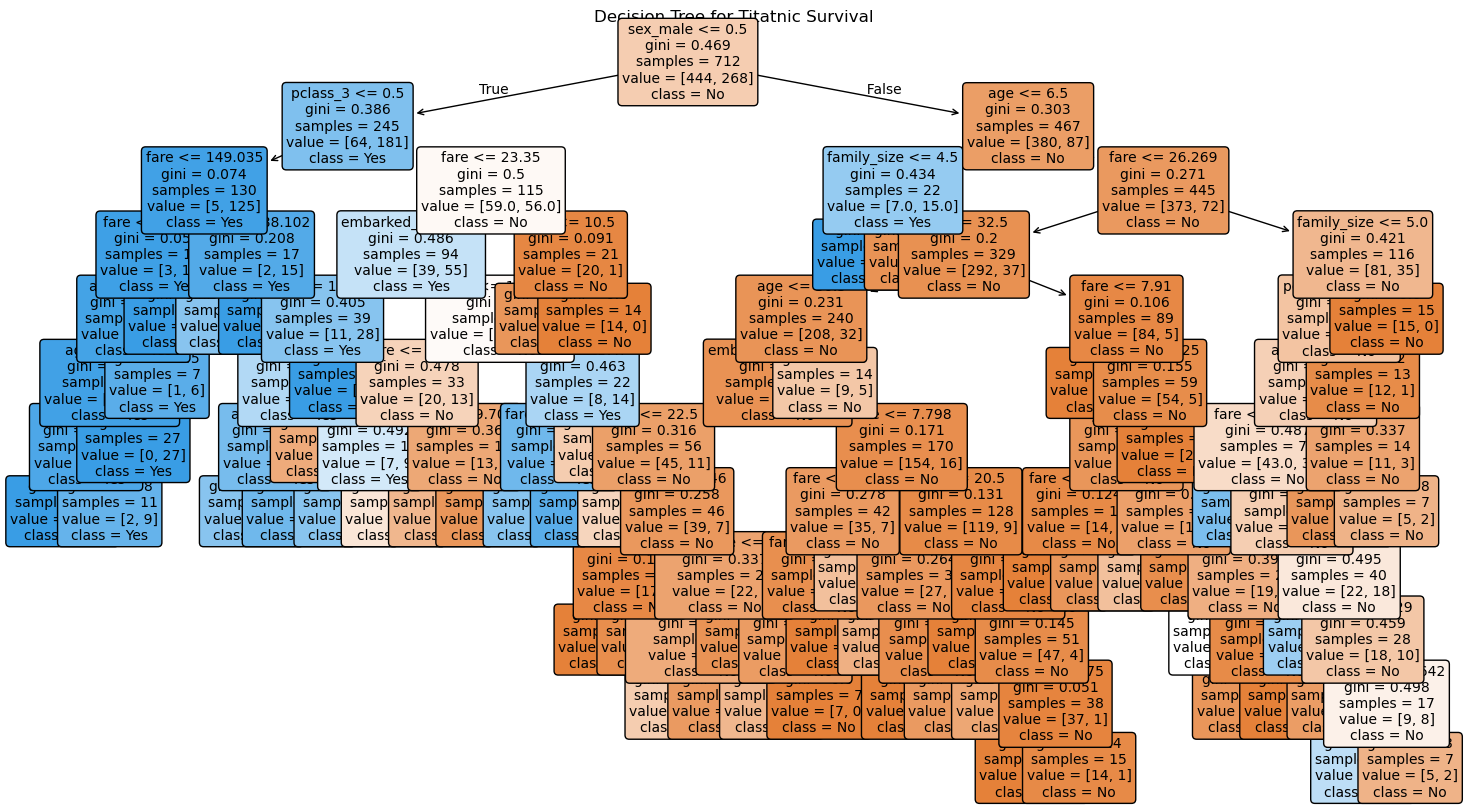

In [45]:
plt.figure(figsize=(18, 10))
plot_tree(model,feature_names=X.columns,class_names=['No', 'Yes'],   filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree for Titatnic Survival ")
plt.show()

<div style="border-bottom: 3px solid #64748b; padding: 8px 0; margin: 25px 0;">
<h3>📌 Final Summary</h3></div>


<div style="background-color: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 5px solid #2e7d32;">
This project applies a Decision Tree classifier to predict passenger survival on the Titanic dataset, with a strong emphasis on feature engineering and model interpretability. Starting from raw passenger records, the project addresses missing data, categorical encoding, and feature redundancy to improve predictive performance while avoiding data leakage. Key engineered features include passenger title groups derived from names, family structure indicators, cabin deck information, and log-transformed fare values. Decision Tree hyperparameters such as maximum depth, minimum samples per split, and minimum samples per leaf were systematically tuned to balance bias and variance. The final optimized model achieves <strong> ~87.15% accuracy </strong>, demonstrating that careful feature selection and tree regularization can substantially improve performance while preserving explainability.
</ul>
</div>
